In [1]:
from scipy.io import loadmat
from scipy.stats import multivariate_normal
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

import newton_1D as newton
np.random.seed(42)

import os

# Create directory if it doesn't exist
os.makedirs("DATA", exist_ok=True)

n_samples = 100000

# Problem 
(From "Generalized Nonlinear Inverse Problems Solved Using the Least Squares Criterion" by TARANTOLA.)



Assuming a two-dimensional problem, it may be shown that
 
 \begin{equation}
 u(x) = \displaystyle \int\limits_{a}^{b} 
    \log
        \frac{(x-w)^{2}+ H^{2}}
             {(x-w)^{2} + \big [H - z(w) \big ]^{2}}dw. ~~~~~~~~~~~~~~~~~~~~~~~~~ (1)
 \end{equation}
 
We want to solve the inverse problem of estimating thefunction $z(w)$ from a finite set of measurements of the anomaly 

$$d_0 =  \mathbf{u}$$

 where $\mathbf{d}_0$ is the observational data. Equation (1) defines a non linear operator which may bewritten as
 
 \begin{equation}
     \mathbf{u} = \mathbf G (\mathbf z) + \boldsymbol{\epsilon}, \label{c3_1}
 \end{equation}
 
 
 where  $\boldsymbol{\epsilon} \sim \mathcal{N}(0,\mathbf{C}_{d_0,d_0})$ accounts for the errors in the data. We assume that the observation error covariance is given by:

\begin{equation}
\mathbf{C}_{d_0,d_0} =  0.01 \cdot \mathbf{I}
\end{equation}
 
 
 
 
Assuming that we have a first guess, $ \mathbf z _0(w)$, for the parameters, such that:
 
 \begin{equation}
     \mathbf{z} =  \mathbf z _0(w) + \mathbf{f}, \label{c3_2}
 \end{equation}
 
 where $\mathbf{f} \sim \mathcal{N}(0,\mathbf{C}_{z,z}) $  represents the unknown errors in the first guess.  
 
 For this experiment, we assume that:
 
 \begin{equation}
     \mathbf z _0(w) = 0
 \end{equation}
 
 and 
 
 \begin{equation}
\mathbf{C}_{z,z} =  \sigma ^2 \exp \bigg \{ -\frac{1}{2} \frac{w-w'}{\Delta ^2}\bigg \} 
\end{equation}
 
<!--  where $\sigma = 5$km and $\Delta  = 1$ km -->
  
 
\begin{equation}
~~~~~~~~~~~~~~~~~~~~~~~~~ 
 \end{equation}





## Set up parameters

In [2]:
H = 10.0
n = 100                   
wmin, wmax = 0.0, 100.0  
w = np.linspace(wmin, wmax, n)


maxz = 2.5


m = 15
x = np.linspace(wmin, wmax, m)


sigma_d = 0.1
Cd = sigma_d**2 * np.eye(m)
Cd_inv = np.linalg.inv(Cd)

## True parameters $z_{\text{true}}$

In [3]:
def z_true(w,maxz):
    
    m = len(w)
    a = int(2 * m / 5)  
    b = int(m / 2)    
    c = int(3 * m / 5)  
    
    ztrue = np.zeros(m)
    ztrue[a:c+1] = maxz * np.exp(-5.0 * (w[a:c+1] - w[b])**2 / m)
    
    return ztrue

## $\mathbf u = \mathbf G(\mathbf z)$ and $J$

In [4]:
def forward_Gz(x, w, z, H): 
    n = x.size
    m = w.size
    
    u = np.empty(n, dtype=float)
    
    for j in range(n):
        X = float(x[j])
        num = (X - w) ** 2 + H ** 2
        den = (X - w) ** 2 + (H - z) ** 2
        ffun = np.log(num / den) # should be (m,) 
        
        f = np.asarray(ffun).ravel()
        
        u[j] = np.trapz(f, w)
            
    return u

In [5]:
def Jfun(z, x, w, H):
    X, W = np.meshgrid(x, w, indexing='ij')  
    Z = z[np.newaxis, :]                     

    denominator = (X - W)**2 + (H - Z)**2
    J = 2.0 * (H - Z) / denominator             
    J *= (w[1] - w[0])                      
    return J  

## Simulated data

In [6]:
def synthetic_data(x, w, z, H, sigma_d, rng):
    n = len(x)
    epsl = rng.normal(0, sigma_d, size=n)   
    data = forward_Gz(x, w, z, H) + epsl
    return data

In [7]:
ztrue =  z_true(w,maxz)
G     =  forward_Gz(x, w, ztrue,H)

rng_obs = np.random.default_rng(0)
d = synthetic_data(x, w, ztrue, H, sigma_d, rng_obs)

np.savetxt(os.path.join("DATA","z_true.csv"), ztrue, delimiter=",")
np.savetxt(os.path.join("DATA","u_obs.csv"), d, delimiter=",")

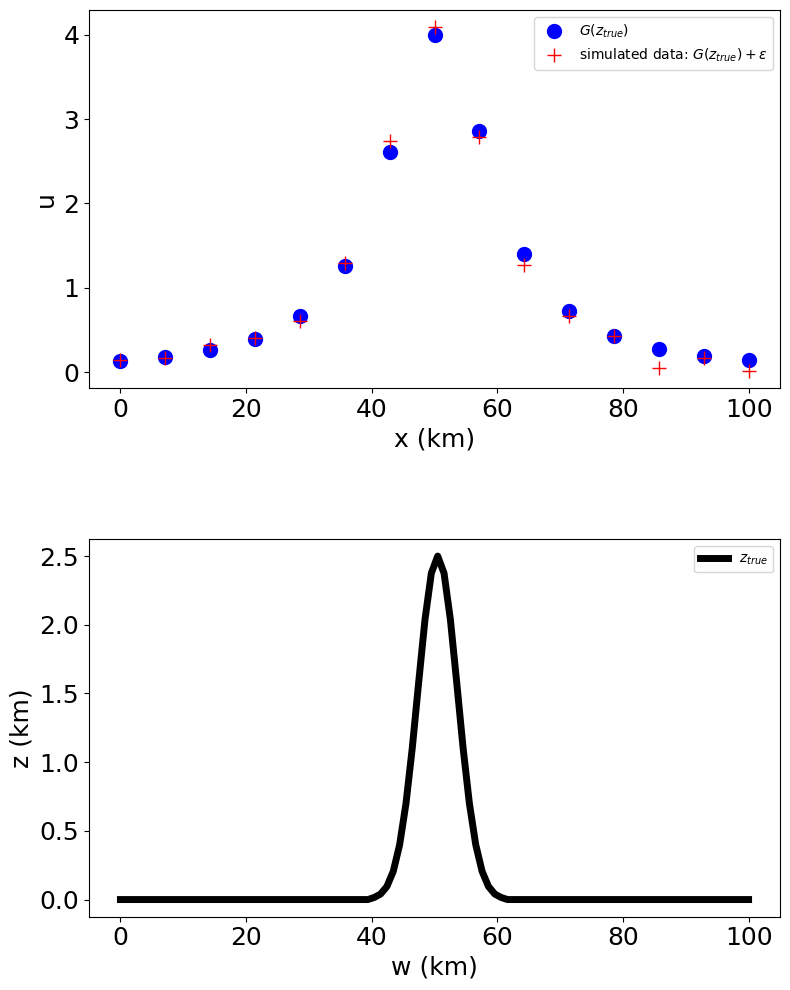

In [8]:
fig = plt.subplots(2, 1, figsize=(8, 10), sharex=False) 


plt.subplot(2,1,2)
plt.plot(w, ztrue, 'k-', label = '$z_{true}$', linewidth=5)
plt.xlabel('w (km)', fontsize=18)
plt.ylabel('z (km)', fontsize=18)
plt.legend()
plt.tick_params(labelsize=18)


plt.subplot(2,1,1)
plt.plot(x, G, 'bo', label = '$G(z_{true})$', markersize=10)
plt.plot(x, d, 'r+', label = r'simulated data: $G(z_{true}) + \epsilon$', markersize=10)
plt.xlabel('x (km)', fontsize=18)
plt.ylabel('u', fontsize=18)
plt.legend()
plt.tick_params(labelsize=18)


plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
# plt.savefig("true_model.png", dpi=300, bbox_inches='tight')
plt.show()
plt.show()


## Prior estimate $\mathbf z_0$ and $\mathbf{C}_{z,z}$

In [9]:
z0 = np.zeros(n)

sigma_z = 1 

Cz = sigma_z**2 * np.eye(n)    

# Gauss-Newton Method

In [10]:
K = 10    # number iterations
zhat = newton.inv_DDCP(x, w, H, d, sigma_d, z0, Cz, K,forward_Gz)

np.savetxt(os.path.join("DATA","z_GN.csv"),  zhat[:, -1],  delimiter=",")

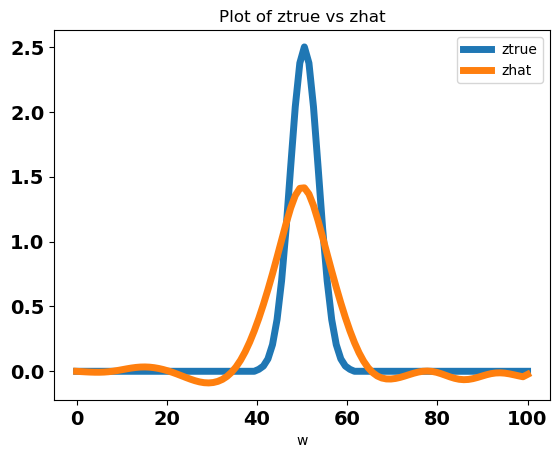

In [11]:
plt.figure(2); plt.clf()
plt.plot(w, ztrue, label='ztrue', linewidth=5)
plt.plot(w, zhat[:, -1], label='zhat', linewidth=5)
plt.title('Plot of ztrue vs zhat')
plt.xlabel('w')
ax = plt.gca()
ax.tick_params(labelsize=14)
for label in (ax.get_xticklabels() + ax.get_yticklabels()):
    label.set_fontweight('bold')
plt.legend()

In [12]:
def generate_observations(z_samples, x, w, H, sigma_d, seed=11):
    """
    For each z_i in z, compute d_i = G(z_i) + eps_i.
    Returns d with shape (N, m).
    """
    rng = np.random.default_rng(seed)
    N = z_samples.shape[0]
    m = x.size

    d_noiseless = np.array([forward_Gz(x, w, z, H)for z in z_samples]) 
    eps = rng.normal(0, sigma_d, size=(N, m))
    d = d_noiseless + eps
    return d

# Sampling from a Gaussian prior

In [13]:
def sample_gaussian_prior(n_samples, z0, Cz, seed = 10):
    z_gauss = multivariate_normal.rvs(mean = z0, cov = Cz, size = n_samples)
    return z_gauss

In [14]:
z_gauss = sample_gaussian_prior(n_samples, z0, Cz, seed = 10)
d_gauss = generate_observations(z_gauss, x, w, H, sigma_d, seed=11)

np.savetxt(os.path.join("DATA","z_gaussian.csv"), z_gauss, delimiter=",")
np.savetxt(os.path.join("DATA","d_gaussian.csv"), d_gauss, delimiter=",")

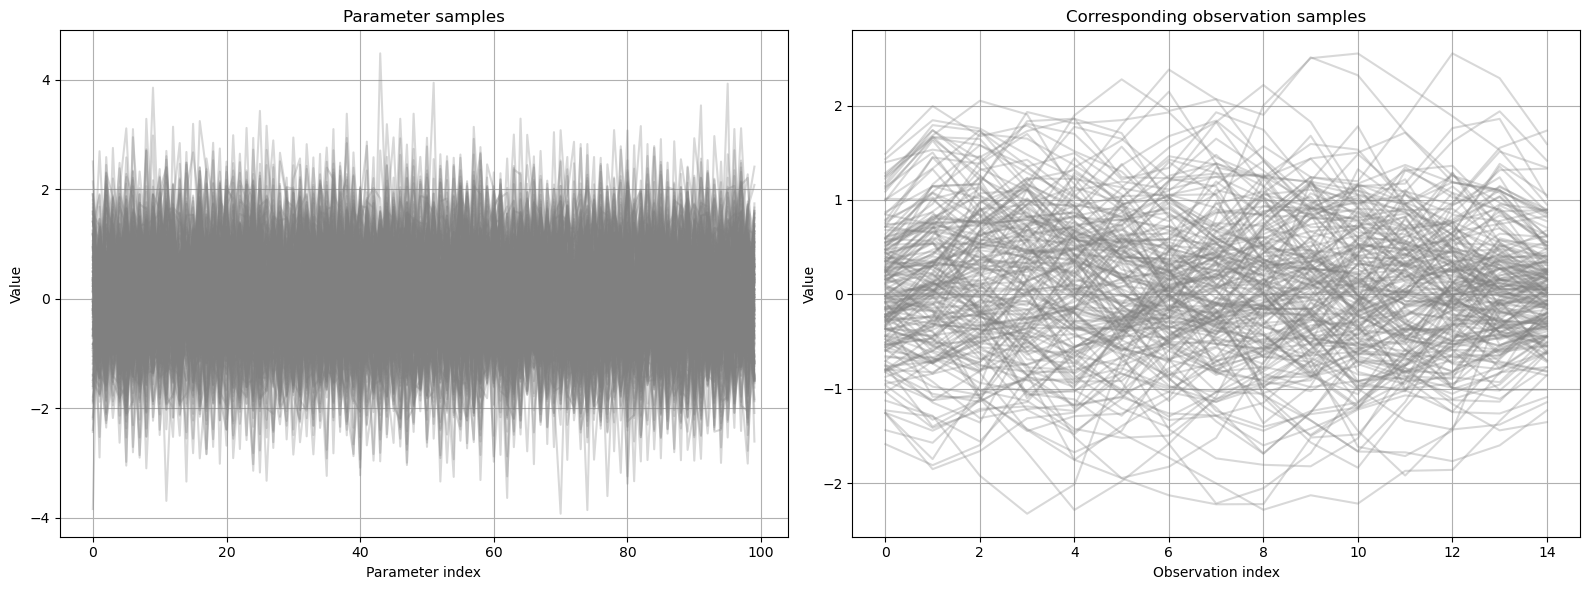

In [15]:
plt.figure(figsize=(16, 6))

# --- Parameter samples ---
plt.subplot(1, 2, 1)
for i in range(min(200, n_samples)):
    plt.plot(z_gauss[i], color='gray', alpha=0.3)

plt.xlabel('Parameter index')
plt.ylabel('Value')
plt.title('Parameter samples')
plt.grid(True)

# --- Observation samples ---
plt.subplot(1, 2, 2)
for i in range(min(200, n_samples)):
    plt.plot(d_gauss[i], color='gray', alpha=0.3)

plt.xlabel('Observation index')
plt.ylabel('Value')
plt.title('Corresponding observation samples')
plt.grid(True)

plt.tight_layout()
plt.show()


# Sampling from a Laplace prior

In [16]:
def sample_laplace_prior(n_samples, z0, Cz, seed=10):
    """
    Draw N samples from independent Laplace prior.
    b_j = sqrt(diag(Cz)_j / 2), consistent with L1 regularization.
    Components are independent — only diag(Cz) is used.
    Returns Z shape (N, n)
    """
    rng = np.random.default_rng(seed)
    n = z0.size
    b = np.sqrt(np.diag(Cz) / 2.0)              
    eta = rng.laplace(0.0, 1.0, size=(n_samples, n)) * b[np.newaxis, :]
    z = z0.reshape(1, -1) + eta
    return z

In [17]:
z_laplace = sample_laplace_prior(n_samples, z0, Cz, seed=20)
d_laplace = generate_observations(z_laplace, x, w, H, sigma_d, seed=21)

np.savetxt(os.path.join("DATA","z_laplace.csv"), z_laplace, delimiter=",")
np.savetxt(os.path.join("DATA","d_laplace.csv"), d_laplace, delimiter=",")

# Sampling from a total Variation prior

In [18]:
def sample_tv(n_samples, z0, sigma_z, seed=10):
    rng = np.random.default_rng(seed)
    n = z0.size
    z = np.zeros((n_samples, n))
    b_grad = 1.0 / np.sqrt(2 * n)   # raw, unscaled

    for i in range(n_samples):
        u = np.zeros(n)
        for k in range(n - 1):
            u[k + 1] = u[k] + rng.laplace(0.0, b_grad)
        u -= np.mean(u)
        z[i] = z0 + u

    # Rescale perturbations so the global std equals sigma_z.
    perturb  = z - z0.reshape(1, -1)          # (N, n)
    # std of each component across samples, then average across components
    mean_marginal_std = perturb.std(axis=0).mean()
    perturb *= sigma_z / mean_marginal_std
    z = z0.reshape(1, -1) + perturb
    return z

In [19]:
b_grad = sigma_z / np.sqrt(2 * n) 

z_tv = sample_tv(n_samples, z0, sigma_z, seed=30)
d_tv = generate_observations(z_tv, x, w, H, sigma_d, seed=31)

np.savetxt(os.path.join("DATA","z_tv.csv"), z_tv, delimiter=",")
np.savetxt(os.path.join("DATA","d_tv.csv"), d_tv, delimiter=",")

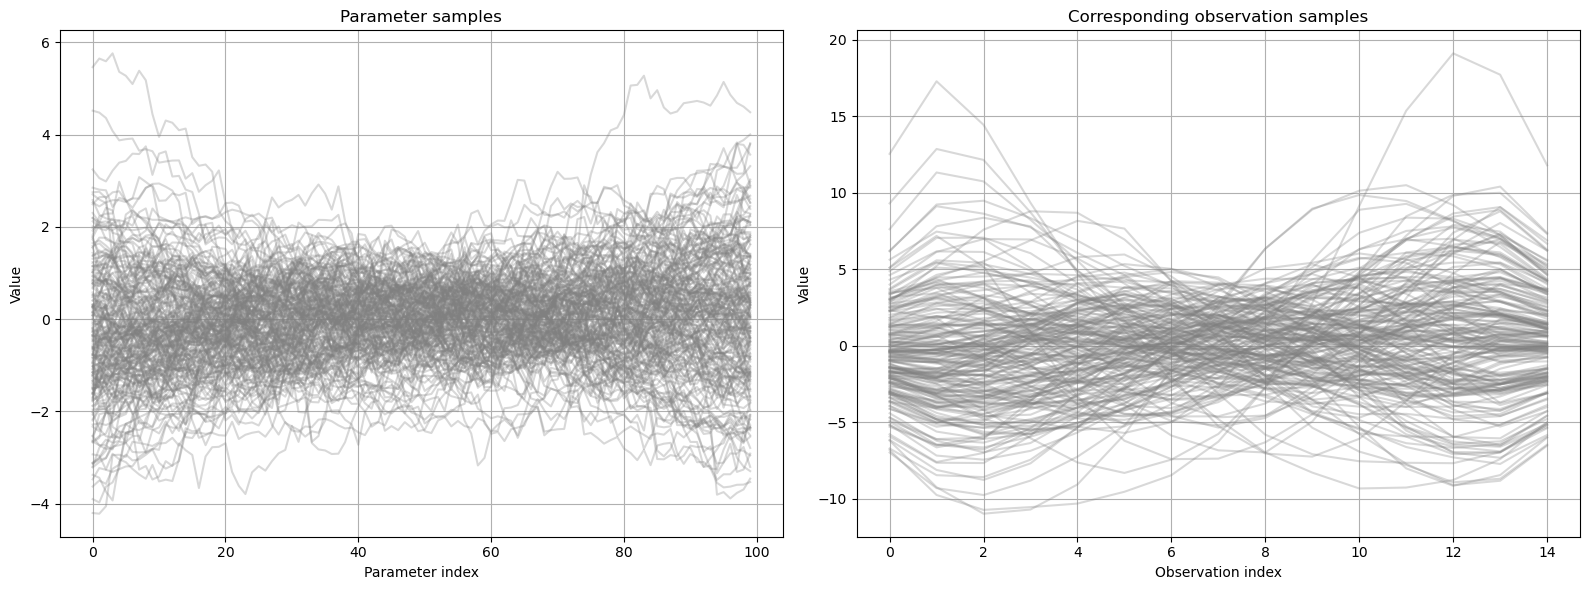

In [20]:
plt.figure(figsize=(16, 6))

# --- Subplot 1: Parameter samples ---
plt.subplot(1, 2, 1)
for i in range(min(200, n_samples)):
    plt.plot(z_tv[i], color='gray', alpha=0.3)

plt.xlabel('Parameter index')
plt.ylabel('Value')
plt.title('Parameter samples')
plt.grid(True)

# --- Subplot 2: Observation samples ---
plt.subplot(1, 2, 2)
for i in range(min(200, n_samples)):
    plt.plot(d_tv[i], color='gray', alpha=0.3)

plt.xlabel('Observation index')
plt.ylabel('Value')
plt.title('Corresponding observation samples')
plt.grid(True)

plt.tight_layout()
plt.show()


# Uniform samples

In [21]:
def sample_uniform_prior(n_samples, z0, a_uniform, seed=10):
    """
    Draw N samples from independent uniform prior:
   z     z_j ~ Uniform(z0_j - a, z0_j + a)
    
    a chosen so marginal std matches sigma_z:
        Var(Uniform(-a, a)) = a^2 / 3  =>  a = sigma_z * sqrt(3)
    Returns Z shape (N, n)
    """
    rng = np.random.default_rng(seed)
    n = z0.size
    eta = rng.uniform(-a_uniform, a_uniform, size=(n_samples, n))
    z = z0.reshape(1, -1) + eta
    return z

In [22]:
a_uniform = sigma_z * np.sqrt(3)   # ~3.46 for sigma_z = 2

z_uniform = sample_uniform_prior(n_samples, z0, a_uniform, seed=10)
d_uniform = generate_observations(z_uniform, x, w, H, sigma_d, seed=11)

np.savetxt(os.path.join("DATA","z_uniform.csv"), z_uniform, delimiter=",")
np.savetxt(os.path.join("DATA","d_uniform.csv"), d_uniform, delimiter=",")

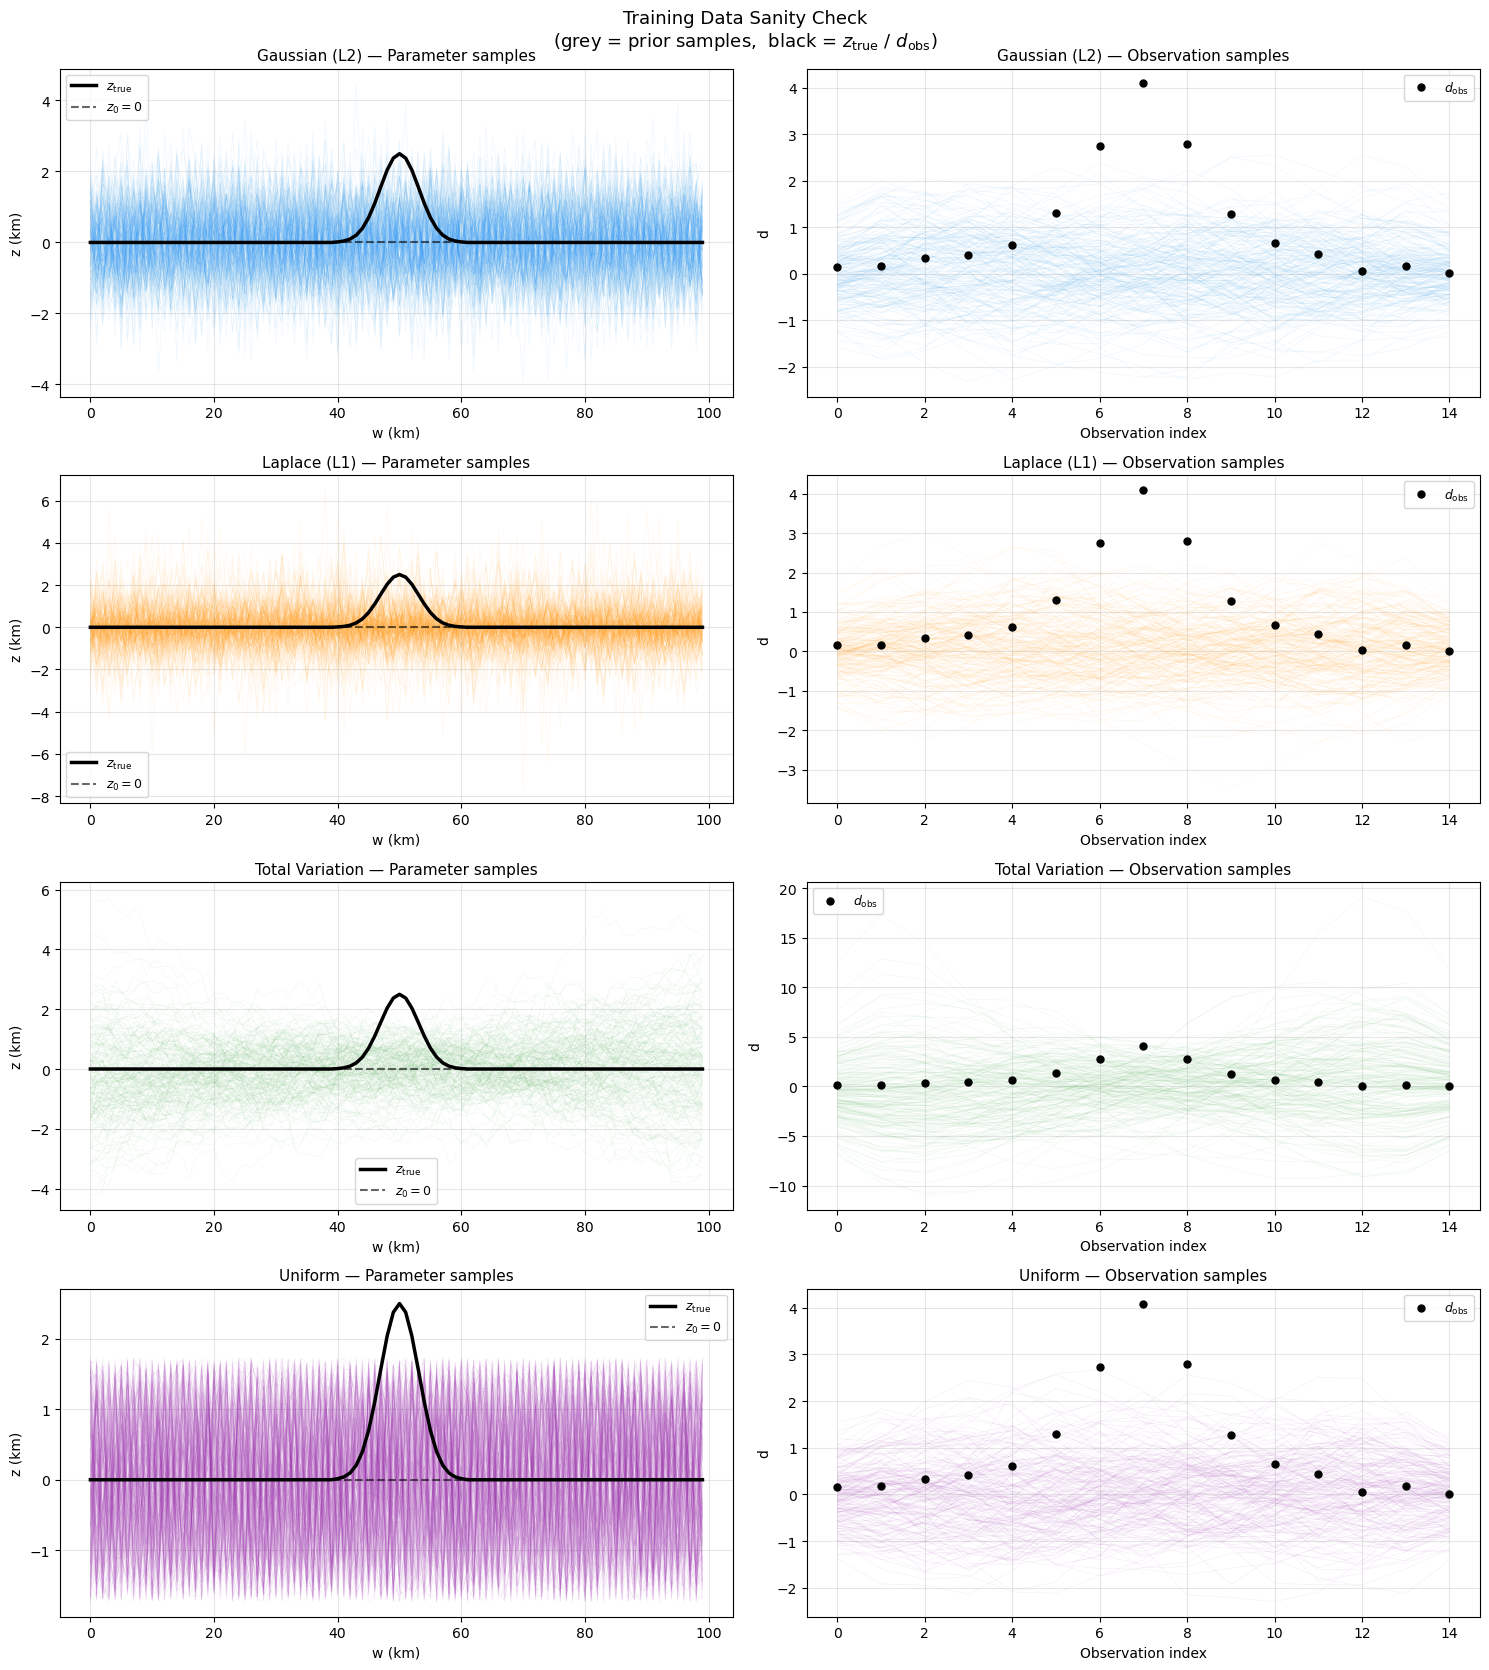

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(15, 17))  # 3 -> 4 rows

datasets = [
    ("Gaussian (L2)",    z_gauss, d_gauss, "#2196F3"),
    ("Laplace (L1)",     z_laplace,  d_laplace,  "#FF9800"),
    ("Total Variation",  z_tv,       d_tv,        "#4CAF50"),
    ("Uniform",          z_uniform,  d_uniform,   "#9C27B0"),  # new
]
for row, (label, zs, ds, color) in enumerate(datasets):
    # Parameter samples
    ax = axes[row, 0]
    for i in range(min(200, n_samples)):
        ax.plot(zs[i], color=color, alpha=0.07, linewidth=0.5)
    ax.plot(ztrue, "k-", linewidth=2.5, label=r"$z_{\rm true}$", zorder=5)
    ax.plot(z0,     "k--", linewidth=1.5, label=r"$z_0 = 0$",      zorder=5, alpha=0.6)
    ax.set_title(f"{label} — Parameter samples", fontsize=11)
    ax.set_xlabel("w (km)"); ax.set_ylabel("z (km)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Observation samples
    ax = axes[row, 1]
    for i in range(min(200, n_samples)):
        ax.plot(ds[i], color=color, alpha=0.07, linewidth=0.5)
    ax.plot(d, "ko", markersize=5, label=r"$d_{\rm obs}$", zorder=5)
    ax.set_title(f"{label} — Observation samples", fontsize=11)
    ax.set_xlabel("Observation index"); ax.set_ylabel("d")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Training Data Sanity Check\n"
             r"(grey = prior samples,  black = $z_{\rm true}$ / $d_{\rm obs}$)",
             fontsize=13)
plt.tight_layout()
# plt.savefig("sanity_check.png", dpi=150)
plt.show()

In [24]:
# ──────────────────────────────────────────────────────────
# 8.  Print statistics — confirm comparable variance
# ──────────────────────────────────────────────────────────
print("\n" + "="*52)
print(f"  {'Dataset':<22}  {'z std':>8}  {'d std':>8}")
print("="*52)
for label, zs, ds, _ in datasets:
    print(f"  {label:<22}  {zs.std():>8.3f}  {ds.std():>8.3f}")
print("="*52)
print("\nAll CSV files ready. Run nn_inverse.py next.\n")



  Dataset                    z std     d std
  Gaussian (L2)              1.000     0.763
  Laplace (L1)               1.000     0.770
  Total Variation            1.025     3.220
  Uniform                    1.000     0.762

All CSV files ready. Run nn_inverse.py next.

